# PyTorch Dataset + Fusion Baseline

هذه المرحلة تأتي بعد إنشاء:

```text
Wald_Data_GSD/
├── Patches/
│   ├── train/
│   ├── val/
│   └── test/
├── patch_manifest.csv
└── dataset_config.json
```

## الهدف

نبني Baseline بسيط قبل تعديل HAT:

```text
LR-MS 6×64×64
     ↓ Bicubic ×4
6×256×256
     +
PAN 1×256×256
     ↓ Concatenate
7×256×256
     ↓ Small CNN
Predicted MS 6×256×256
```

هذا النموذج ليس النموذج النهائي للـPaper. دوره:

1. التأكد أن الـDataset Loader صحيح.
2. التأكد أن عملية التدريب كاملة تعمل.
3. إنشاء نتيجة Baseline نقارن بها HAT لاحقًا.
4. قياس هل استخدام PAN يحسن النتيجة مقارنةً بـBicubic فقط.


## 1) تفعيل GPU

في Colab:

```text
Runtime → Change runtime type → T4 GPU
```


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("يفضل تشغيل الـNotebook باستخدام T4 GPU.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2) تثبيت المكتبات وربط Google Drive

In [2]:
!pip install -q numpy pandas matplotlib scikit-image tqdm

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 3) المسارات والإعدادات

In [3]:
from pathlib import Path
import json
import random
import os

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

DATA_DIR = PROJECT_DIR / "Wald_Data_GSD"
PATCHES_DIR = DATA_DIR / "Patches"

TRAIN_DIR = PATCHES_DIR / "train"
VAL_DIR = PATCHES_DIR / "val"
TEST_DIR = PATCHES_DIR / "test"

OUTPUT_DIR = PROJECT_DIR / "Fusion_Baseline_Results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR / "best_fusion_baseline.pth"
LAST_MODEL_PATH = OUTPUT_DIR / "last_fusion_baseline.pth"
STATS_PATH = OUTPUT_DIR / "train_normalization_stats.json"
HISTORY_PATH = OUTPUT_DIR / "training_history.json"
TEST_METRICS_PATH = OUTPUT_DIR / "test_metrics.json"

print("Train exists:", TRAIN_DIR.exists())
print("Val exists  :", VAL_DIR.exists())
print("Test exists :", TEST_DIR.exists())
print("Output      :", OUTPUT_DIR)

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not folder.exists():
        raise FileNotFoundError(folder)

SEED = 42
BATCH_SIZE = 4
NUM_WORKERS = 2

# ابدأ بـ 5 للتجربة، ثم اجعلها 30 أو 50 للتدريب الكامل
EPOCHS = 5

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-6

SCALE = 4
MS_BANDS = 6

# النموذج الخفيف المبدئي
FEATURES = 48
RESIDUAL_BLOCKS = 6

random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import numpy as np

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Settings loaded.")


Train exists: True
Val exists  : True
Test exists : True
Output      : /content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results
Settings loaded.


## 4) فحص عدد الملفات

In [4]:
train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("Train:", len(train_files))
print("Val  :", len(val_files))
print("Test :", len(test_files))

assert len(train_files) == 231
assert len(val_files) == 22
assert len(test_files) == 22


Train: 231
Val  : 22
Test : 22


## 5) حساب التطبيع من Train فقط

سنحسب Percentile 1 و99 من ملفات Train فقط.

- الـ6 MS Bands تستخدم نفس القيم لتطبيع LR-MS وTarget-MS.
- PAN لها قيم مستقلة.
- لا نستخدم Validation أو Test في حساب التطبيع، لمنع Data Leakage.


In [5]:
from tqdm.auto import tqdm
import numpy as np


def collect_train_stats(files):
    ms_values = [[] for _ in range(MS_BANDS)]
    pan_values = []

    for file_path in tqdm(files, desc="Collecting train statistics"):
        with np.load(file_path) as sample:
            target = sample["target_ms"]
            pan = sample["pan"][0]

        for band_index in range(MS_BANDS):
            band = target[band_index]
            valid = band[band > 0]

            if valid.size:
                # Sampling يقلل استهلاك RAM مع الحفاظ على تقدير جيد
                step = max(1, valid.size // 20000)
                ms_values[band_index].append(valid[::step])

        valid_pan = pan[pan > 0]

        if valid_pan.size:
            step = max(1, valid_pan.size // 20000)
            pan_values.append(valid_pan[::step])

    stats = {
        "ms": [],
        "pan": {},
    }

    for band_index in range(MS_BANDS):
        values = np.concatenate(ms_values[band_index]).astype(np.float32)

        low = float(np.percentile(values, 1))
        high = float(np.percentile(values, 99))

        if high <= low:
            high = low + 1.0

        stats["ms"].append({
            "band": band_index + 1,
            "p01": low,
            "p99": high,
            "mean": float(values.mean()),
            "std": float(values.std()),
        })

    values = np.concatenate(pan_values).astype(np.float32)

    low = float(np.percentile(values, 1))
    high = float(np.percentile(values, 99))

    if high <= low:
        high = low + 1.0

    stats["pan"] = {
        "p01": low,
        "p99": high,
        "mean": float(values.mean()),
        "std": float(values.std()),
    }

    return stats


stats = collect_train_stats(train_files)

with open(STATS_PATH, "w", encoding="utf-8") as file:
    json.dump(stats, file, indent=2, ensure_ascii=False)

print("Saved:", STATS_PATH)

for item in stats["ms"]:
    print(
        f"Band {item['band']}:",
        f"P01={item['p01']:.2f}",
        f"P99={item['p99']:.2f}"
    )

print(
    "PAN:",
    f"P01={stats['pan']['p01']:.2f}",
    f"P99={stats['pan']['p99']:.2f}"
)


Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results/train_normalization_stats.json
Band 1: P01=788.00 P99=4775.00
Band 2: P01=799.00 P99=3941.00
Band 3: P01=838.00 P99=3032.00
Band 4: P01=804.00 P99=5393.00
Band 5: P01=849.00 P99=5224.00
Band 6: P01=967.00 P99=2541.00
PAN: P01=769.00 P99=4325.00


## 6) دوال التطبيع وإرجاع القيم الأصلية

In [6]:
MS_LOW = np.array(
    [item["p01"] for item in stats["ms"]],
    dtype=np.float32,
)[:, None, None]

MS_HIGH = np.array(
    [item["p99"] for item in stats["ms"]],
    dtype=np.float32,
)[:, None, None]

PAN_LOW = np.float32(stats["pan"]["p01"])
PAN_HIGH = np.float32(stats["pan"]["p99"])


def normalize_ms(array):
    array = array.astype(np.float32)

    return np.clip(
        (array - MS_LOW) / (MS_HIGH - MS_LOW),
        0,
        1,
    )


def denormalize_ms(array):
    return (
        array * (MS_HIGH - MS_LOW)
        + MS_LOW
    )


def normalize_pan(array):
    array = array.astype(np.float32)

    return np.clip(
        (array - PAN_LOW) / (PAN_HIGH - PAN_LOW),
        0,
        1,
    )


## 7) إنشاء PyTorch Dataset

In [7]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F


class WaldPatchDataset(Dataset):
    def __init__(self, folder, augment=False):
        self.files = sorted(Path(folder).glob("*.npz"))
        self.augment = augment

        if not self.files:
            raise RuntimeError(f"No NPZ files found in {folder}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file_path = self.files[index]

        with np.load(file_path) as sample:
            lr_ms = sample["lr_ms"].copy()
            pan = sample["pan"].copy()
            target = sample["target_ms"].copy()

        lr_ms = normalize_ms(lr_ms)
        target = normalize_ms(target)
        pan = normalize_pan(pan)

        lr_ms = torch.from_numpy(lr_ms).float()
        pan = torch.from_numpy(pan).float()
        target = torch.from_numpy(target).float()

        # Augmentation متطابق بين الصور الثلاث
        if self.augment:
            if random.random() < 0.5:
                lr_ms = torch.flip(lr_ms, dims=[2])
                pan = torch.flip(pan, dims=[2])
                target = torch.flip(target, dims=[2])

            if random.random() < 0.5:
                lr_ms = torch.flip(lr_ms, dims=[1])
                pan = torch.flip(pan, dims=[1])
                target = torch.flip(target, dims=[1])

            rotations = random.randint(0, 3)

            if rotations:
                lr_ms = torch.rot90(
                    lr_ms,
                    rotations,
                    dims=[1, 2],
                )

                pan = torch.rot90(
                    pan,
                    rotations,
                    dims=[1, 2],
                )

                target = torch.rot90(
                    target,
                    rotations,
                    dims=[1, 2],
                )

        return {
            "lr_ms": lr_ms,
            "pan": pan,
            "target_ms": target,
            "file": file_path.name,
        }


train_dataset = WaldPatchDataset(TRAIN_DIR, augment=True)
val_dataset = WaldPatchDataset(VAL_DIR, augment=False)
test_dataset = WaldPatchDataset(TEST_DIR, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


Train batches: 58
Val batches  : 6
Test batches : 6


## 8) فحص Batch قبل التدريب

In [8]:
batch = next(iter(train_loader))

print("LR-MS :", batch["lr_ms"].shape)
print("PAN   :", batch["pan"].shape)
print("Target:", batch["target_ms"].shape)
print("Files :", batch["file"][:2])

assert batch["lr_ms"].shape[1:] == (6, 64, 64)
assert batch["pan"].shape[1:] == (1, 256, 256)
assert batch["target_ms"].shape[1:] == (6, 256, 256)


LR-MS : torch.Size([4, 6, 64, 64])
PAN   : torch.Size([4, 1, 256, 256])
Target: torch.Size([4, 6, 256, 256])
Files : ['train_y0832_x0320.npz', 'train_y0640_x0000.npz']


## 9) عرض عينة بعد التطبيع

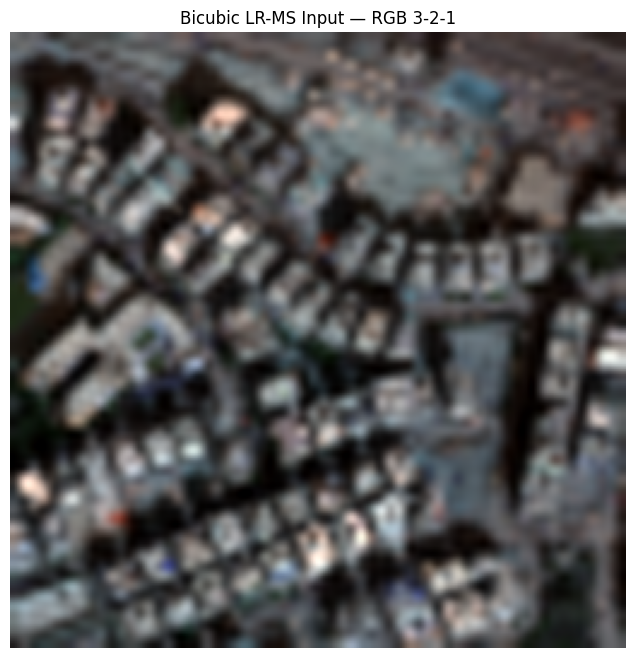

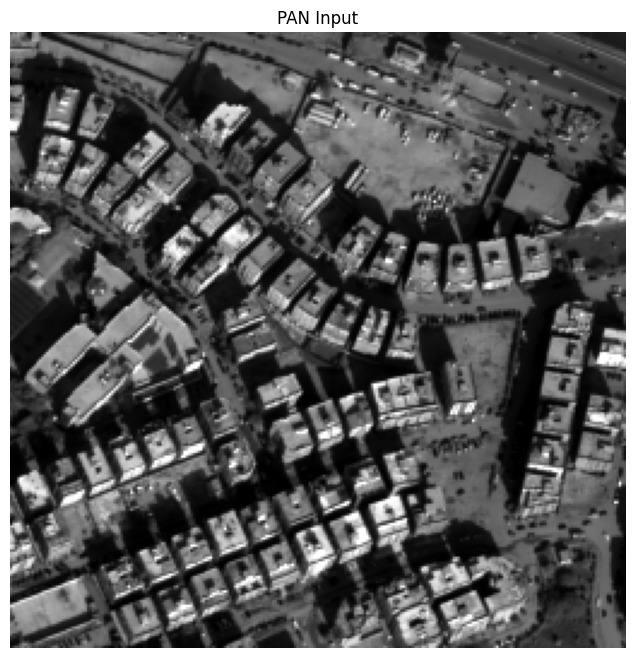

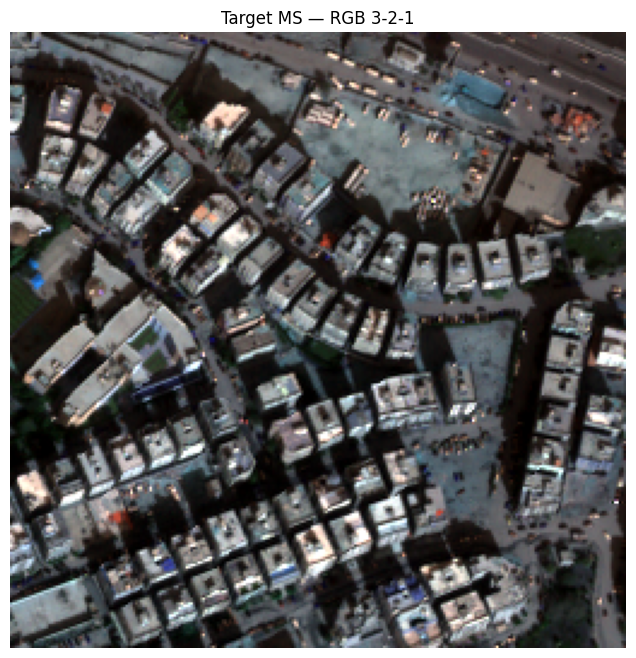

In [9]:
import matplotlib.pyplot as plt

sample_lr = batch["lr_ms"][0]
sample_pan = batch["pan"][0, 0]
sample_target = batch["target_ms"][0]

sample_lr_up = F.interpolate(
    sample_lr.unsqueeze(0),
    scale_factor=SCALE,
    mode="bicubic",
    align_corners=False,
)[0]


def rgb321_tensor(tensor):
    return torch.stack(
        [
            tensor[2],
            tensor[1],
            tensor[0],
        ],
        dim=-1,
    ).clamp(0, 1).cpu().numpy()


plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(sample_lr_up))
plt.title("Bicubic LR-MS Input — RGB 3-2-1")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(sample_pan.cpu().numpy(), cmap="gray")
plt.title("PAN Input")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(sample_target))
plt.title("Target MS — RGB 3-2-1")
plt.axis("off")
plt.show()


## 10) Baseline Model

النموذج يتنبأ بـResidual فوق صورة LR-MS المكبرة:

```text
Prediction = Bicubic LR-MS + Learned Residual
```

هذا يساعد النموذج على تعلم التفاصيل التي تضيفها PAN بدل إعادة بناء الصورة من الصفر.


In [10]:
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
            ),
            nn.GELU(),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(self, x):
        return x + self.block(x)


class FusionBaseline(nn.Module):
    def __init__(
        self,
        features=48,
        residual_blocks=6,
    ):
        super().__init__()

        self.head = nn.Conv2d(
            7,
            features,
            kernel_size=3,
            padding=1,
        )

        self.body = nn.Sequential(
            *[
                ResidualBlock(features)
                for _ in range(residual_blocks)
            ]
        )

        self.tail = nn.Sequential(
            nn.Conv2d(
                features,
                features,
                kernel_size=3,
                padding=1,
            ),
            nn.GELU(),
            nn.Conv2d(
                features,
                6,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(self, lr_ms, pan):
        upsampled_ms = F.interpolate(
            lr_ms,
            size=pan.shape[-2:],
            mode="bicubic",
            align_corners=False,
        )

        fusion_input = torch.cat(
            [upsampled_ms, pan],
            dim=1,
        )

        features = self.head(fusion_input)
        features = self.body(features)
        residual = self.tail(features)

        prediction = upsampled_ms + residual

        return prediction.clamp(0, 1)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = FusionBaseline(
    features=FEATURES,
    residual_blocks=RESIDUAL_BLOCKS,
).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Device:", device)
print("Parameters:", f"{parameter_count:,}")

with torch.no_grad():
    output = model(
        batch["lr_ms"][:1].to(device),
        batch["pan"][:1].to(device),
    )

print("Output shape:", output.shape)

assert output.shape == (1, 6, 256, 256)


Device: cuda
Parameters: 275,862
Output shape: torch.Size([1, 6, 256, 256])


## 11) Metrics

In [11]:
import math


def batch_psnr(prediction, target):
    mse = torch.mean(
        (prediction - target) ** 2,
        dim=(1, 2, 3),
    )

    psnr = 10 * torch.log10(
        1.0 / torch.clamp(mse, min=1e-12)
    )

    return psnr.mean()


def batch_sam_degrees(prediction, target):
    # رجوع تقريبي إلى DN قبل حساب Spectral Angle
    low = torch.from_numpy(MS_LOW).to(
        prediction.device
    )

    high = torch.from_numpy(MS_HIGH).to(
        prediction.device
    )

    prediction_dn = prediction * (high - low) + low
    target_dn = target * (high - low) + low

    dot = torch.sum(
        prediction_dn * target_dn,
        dim=1,
    )

    pred_norm = torch.linalg.vector_norm(
        prediction_dn,
        dim=1,
    )

    target_norm = torch.linalg.vector_norm(
        target_dn,
        dim=1,
    )

    cosine = dot / torch.clamp(
        pred_norm * target_norm,
        min=1e-8,
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7,
    )

    angle = torch.acos(cosine) * (180.0 / math.pi)

    return angle.mean()


## 12) Bicubic Baseline قبل التدريب

In [12]:
@torch.inference_mode()
def evaluate_bicubic(loader):
    psnr_values = []
    sam_values = []

    for batch in tqdm(loader, desc="Bicubic evaluation"):
        lr_ms = batch["lr_ms"].to(device)
        target = batch["target_ms"].to(device)

        bicubic = F.interpolate(
            lr_ms,
            size=target.shape[-2:],
            mode="bicubic",
            align_corners=False,
        ).clamp(0, 1)

        psnr_values.append(
            batch_psnr(bicubic, target).item()
        )

        sam_values.append(
            batch_sam_degrees(bicubic, target).item()
        )

    return {
        "psnr_db": float(np.mean(psnr_values)),
        "sam_degrees": float(np.mean(sam_values)),
    }


bicubic_val_metrics = evaluate_bicubic(val_loader)
bicubic_test_metrics = evaluate_bicubic(test_loader)

print("Bicubic Validation:", bicubic_val_metrics)
print("Bicubic Test      :", bicubic_test_metrics)


Bicubic evaluation:   0%|          | 0/6 [00:00<?, ?it/s]

Bicubic evaluation:   0%|          | 0/6 [00:00<?, ?it/s]

Bicubic Validation: {'psnr_db': 19.533843358357746, 'sam_degrees': 2.3460435271263123}
Bicubic Test      : {'psnr_db': 18.710798263549805, 'sam_degrees': 2.6229743162790933}


## 13) تدريب النموذج

In [14]:
EPOCHS = 15

In [15]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.L1Loss()

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda"),
)


def train_one_epoch(model, loader):
    model.train()

    total_loss = 0.0
    total_psnr = 0.0
    total_samples = 0

    progress = tqdm(loader, desc="Train", leave=False)

    for batch in progress:
        lr_ms = batch["lr_ms"].to(
            device,
            non_blocking=True,
        )

        pan = batch["pan"].to(
            device,
            non_blocking=True,
        )

        target = batch["target_ms"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda"),
        ):
            prediction = model(lr_ms, pan)
            loss = criterion(prediction, target)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size
        total_psnr += (
            batch_psnr(prediction.detach(), target).item()
            * batch_size
        )

        total_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
    }


@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_sam = 0.0
    total_samples = 0

    for batch in tqdm(loader, desc="Validation", leave=False):
        lr_ms = batch["lr_ms"].to(
            device,
            non_blocking=True,
        )

        pan = batch["pan"].to(
            device,
            non_blocking=True,
        )

        target = batch["target_ms"].to(
            device,
            non_blocking=True,
        )

        prediction = model(lr_ms, pan)
        loss = criterion(prediction, target)

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size
        total_psnr += (
            batch_psnr(prediction, target).item()
            * batch_size
        )

        total_sam += (
            batch_sam_degrees(prediction, target).item()
            * batch_size
        )

        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
        "sam_degrees": total_sam / total_samples,
    }


history = []
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(
        model,
        train_loader,
    )

    val_metrics = evaluate_model(
        model,
        val_loader,
    )

    scheduler.step(val_metrics["loss"])

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": train_metrics["loss"],
        "train_psnr_db": train_metrics["psnr_db"],
        "val_loss": val_metrics["loss"],
        "val_psnr_db": val_metrics["psnr_db"],
        "val_sam_degrees": val_metrics["sam_degrees"],
    }

    history.append(epoch_record)

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train L1: {train_metrics['loss']:.5f} | "
        f"Val L1: {val_metrics['loss']:.5f} | "
        f"Val PSNR: {val_metrics['psnr_db']:.3f} dB | "
        f"Val SAM: {val_metrics['sam_degrees']:.3f}° | "
        f"LR: {current_lr:.2e}"
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "stats": stats,
        "settings": {
            "features": FEATURES,
            "residual_blocks": RESIDUAL_BLOCKS,
            "scale": SCALE,
        },
        "val_metrics": val_metrics,
    }

    torch.save(
        checkpoint,
        LAST_MODEL_PATH,
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]

        torch.save(
            checkpoint,
            BEST_MODEL_PATH,
        )

        print("  Saved new best model.")

with open(HISTORY_PATH, "w", encoding="utf-8") as file:
    json.dump(history, file, indent=2, ensure_ascii=False)

print("Best model:", BEST_MODEL_PATH)
print("History   :", HISTORY_PATH)


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 001/15 | Train L1: 0.03720 | Val L1: 0.03479 | Val PSNR: 25.556 dB | Val SAM: 1.819° | LR: 1.00e-04
  Saved new best model.


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

...

Epoch 014/15 | Train L1: 0.03467 | Val L1: 0.03343 | Val PSNR: 25.779 dB | Val SAM: 1.724° | LR: 1.00e-04
  Saved new best model.


Train:   0%|          | 0/58 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b12d5a5440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x78b12d5a5440>
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^
^  ^ ^ ^  
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^  ^^ ^ ^  ^ ^  ^^^
  File "/u

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 015/15 | Train L1: 0.03460 | Val L1: 0.03334 | Val PSNR: 25.807 dB | Val SAM: 1.721° | LR: 1.00e-04
  Saved new best model.
Best model: /content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results/best_fusion_baseline.pth
History   : /content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results/training_history.json


## 14) رسم منحنيات التدريب

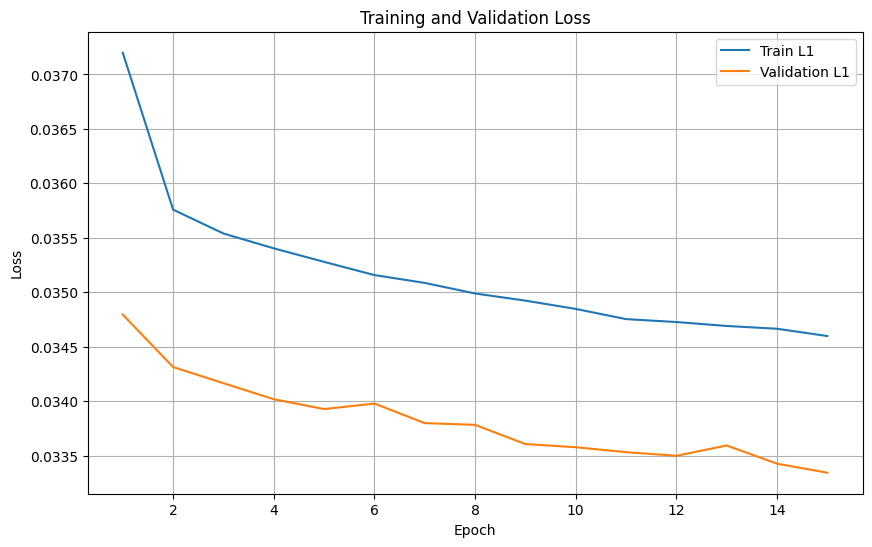

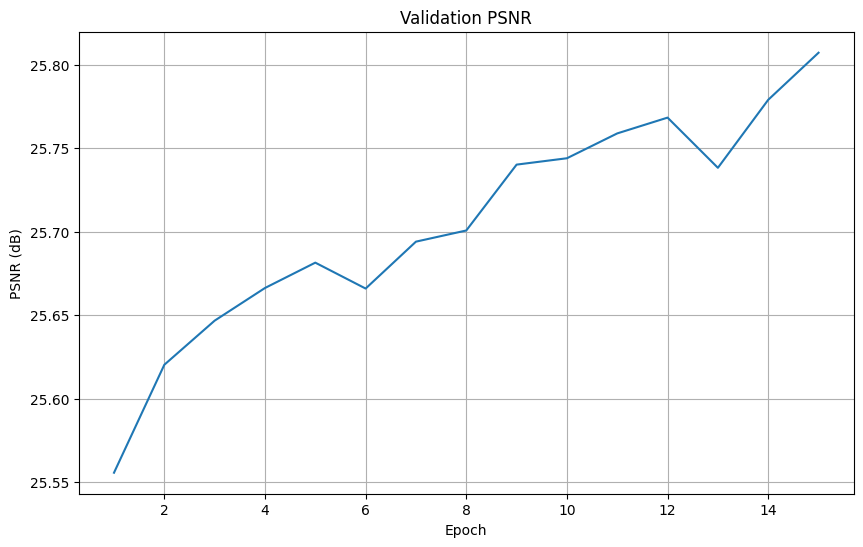

In [16]:
epochs = [item["epoch"] for item in history]

train_losses = [
    item["train_loss"]
    for item in history
]

val_losses = [
    item["val_loss"]
    for item in history
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Train L1")
plt.plot(epochs, val_losses, label="Validation L1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


val_psnr = [
    item["val_psnr_db"]
    for item in history
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_psnr)
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Validation PSNR")
plt.grid()
plt.show()


## 15) اختبار أفضل Model على Test

In [17]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

test_metrics = evaluate_model(
    model,
    test_loader,
)

comparison = {
    "bicubic_test": bicubic_test_metrics,
    "fusion_model_test": test_metrics,
    "psnr_improvement_db": (
        test_metrics["psnr_db"]
        - bicubic_test_metrics["psnr_db"]
    ),
    "sam_improvement_degrees": (
        bicubic_test_metrics["sam_degrees"]
        - test_metrics["sam_degrees"]
    ),
}

with open(
    TEST_METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        comparison,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(json.dumps(
    comparison,
    indent=2,
    ensure_ascii=False,
))

print("Saved:", TEST_METRICS_PATH)


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

{
  "bicubic_test": {
    "psnr_db": 18.710798263549805,
    "sam_degrees": 2.6229743162790933
  },
  "fusion_model_test": {
    "loss": 0.03530742634426464,
    "psnr_db": 25.076182278719816,
    "sam_degrees": 1.9011461518027566
  },
  "psnr_improvement_db": 6.365384015170012,
  "sam_improvement_degrees": 0.7218281644763367
}
Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results/test_metrics.json


## 16) عرض نتيجة Test

In [ ]:
model.eval()

test_batch = next(iter(test_loader))

lr_ms = test_batch["lr_ms"][:1].to(device)
pan = test_batch["pan"][:1].to(device)
target = test_batch["target_ms"][:1].to(device)

with torch.inference_mode():
    prediction = model(lr_ms, pan)

bicubic = F.interpolate(
    lr_ms,
    size=target.shape[-2:],
    mode="bicubic",
    align_corners=False,
).clamp(0, 1)

lr_show = F.interpolate(
    lr_ms,
    size=target.shape[-2:],
    mode="nearest",
)[0]

pan_show = pan[0, 0]
bicubic_show = bicubic[0]
prediction_show = prediction[0]
target_show = target[0]

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(lr_show))
plt.title("Original LR-MS — Nearest View")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(pan_show.cpu().numpy(), cmap="gray")
plt.title("PAN Input")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(bicubic_show))
plt.title("Bicubic Baseline")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(prediction_show))
plt.title("Fusion CNN Prediction")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(target_show))
plt.title("Ground Truth Target MS")
plt.axis("off")
plt.show()

print("Test file:", test_batch["file"][0])


# ماذا ترسل بعد التشغيل؟

ابدأ أولًا بـ:

```python
EPOCHS = 5
```

ثم أرسل:

1. `Bicubic Validation` و`Bicubic Test`.
2. نتائج كل Epoch.
3. نتيجة المقارنة النهائية:
   - Bicubic Test PSNR/SAM.
   - Fusion Model Test PSNR/SAM.
4. صور:
   - Bicubic Baseline.
   - Fusion CNN Prediction.
   - Ground Truth Target MS.

إذا عملت الـNotebook بدون أخطاء وتحسنت النتيجة عن Bicubic، ننتقل بعدها إلى تعديل HAT ليستقبل:

```text
7 Input Channels → HAT → 6 Output Channels
```
